# Bibliotecas Usadas

In [546]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Função para plotar gŕaficos, baseado em duas colunas de um DataFrame

In [547]:
def plotar(dataframe, linha, coluna1, coluna2, titulo, xlabel, ylabel, funcao_comparacao=None, tlabel=None):
    plt.figure()
    plt.plot(dataframe.loc[:linha, coluna1], dataframe.loc[:linha, coluna2], label="Dados Experimentais")
    if funcao_comparacao:
        x = dataframe.loc[:linha, coluna1]
        y_comparacao = funcao_comparacao(x)
        plt.plot(x, y_comparacao, label=tlabel, linestyle="--")
        plt.legend()
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(titulo)
    plt.grid(True)
    plt.show()

# Extração do dados de benchmark

In [548]:
df = pd.read_csv("resultados_benchmark.csv")
df

,idx,algoritmo,num_vertices,num_arestas,densidade,arestas_analisadas,find_calls,union_calls,tempo_execucao_find,tempo_execucao_union,tempo_sort,heap_push,heap_pop,tempo_execucao_heap_ops,num_arestas_mst,tempo_execucao_total
0,1,prim,10,4,0.088889,4,0,0,0.000000,0.000000,0.000000,8,8,0.000003,4,0.000015
1,2,kruskal,10,4,0.088889,3,14,4,0.000005,0.000005,0.000002,0,0,0.000000,4,0.000013
2,3,prim,10,7,0.155556,5,0,0,0.000000,0.000000,0.000000,14,14,0.000002,5,0.000012
3,4,kruskal,10,7,0.155556,5,22,5,0.000004,0.000004,0.000002,0,0,0.000000,5,0.000011
4,5,prim,10,12,0.266667,9,0,0,0.000000,0.000000,0.000000,24,24,0.000005,9,0.000034
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
435,436,kruskal,200,16523,0.830302,448,1794,199,0.002000,0.002000,0.002703,0,0,0.000000,199,0.004040
436,437,prim,200,18490,0.929146,199,0,0,0.000000,0.000000,0.000000,36980,36980,0.004021,199,0.023207
437,438,kruskal,200,18490,0.929146,587,2350,199,0.002433,0.002433,0.003304,0,0,0.000000,199,0.004911
438,439,prim,200,19900,1.000000,199,0,0,0.000000,0.000000,0.000000,39800,39800,0.004792,199,0.026980


# Extração e análise dos dados do algoritmo Prim

## Extração dos dados do Prim e eliminação das colunas que não representam o algoritmo

In [549]:
df_prim = df[df["algoritmo"] == "prim"]
df_prim = df_prim.drop(columns=["algoritmo", "find_calls", "union_calls", "tempo_execucao_find", "tempo_execucao_union", "tempo_sort"])

## Modificação dos índices do DataFrame para melhorar a filtragem

In [550]:
df_prim.reset_index(drop=True, inplace=True)
df_prim.head(10)

,idx,num_vertices,num_arestas,densidade,arestas_analisadas,heap_push,heap_pop,tempo_execucao_heap_ops,num_arestas_mst,tempo_execucao_total
0,1,10,4,0.088889,4,8,8,0.000003,4,0.000015
1,3,10,7,0.155556,5,14,14,0.000002,5,0.000012
2,5,10,12,0.266667,9,24,24,0.000005,9,0.000034
3,7,10,13,0.288889,9,26,26,0.000003,9,0.000015
4,9,10,16,0.355556,9,32,32,0.000003,9,0.000017
5,11,10,29,0.644444,9,58,58,0.000007,9,0.000027
6,13,10,29,0.644444,9,58,58,0.000007,9,0.000027
7,15,10,31,0.688889,9,62,62,0.000007,9,0.000029
8,17,10,36,0.800000,9,72,72,0.000007,9,0.000031
9,19,10,45,1.000000,9,90,90,0.000010,9,0.000038


## Análise do algoritmo Prim com o aumento dos vertices

### Para o pior caso, grafos densos

In [551]:
df_prim_vertice = df_prim.sort_values(by="densidade", ascending=False)
df_prim_vertice.drop_duplicates(subset="num_vertices", keep="first", inplace=True)
df_prim_vertice.sort_values(by="num_vertices", inplace=True)
df_prim_vertice.reset_index(drop=True, inplace=True)
df_prim_vertice

,idx,num_vertices,num_arestas,densidade,arestas_analisadas,heap_push,heap_pop,tempo_execucao_heap_ops,num_arestas_mst,tempo_execucao_total
0,19,10,45,1.0,9,90,90,0.000010,9,0.000038
1,43,20,190,1.0,19,380,380,0.000039,19,0.000158
2,65,30,435,1.0,29,870,870,0.000084,29,0.000361
3,87,40,780,1.0,39,1560,1560,0.000148,39,0.000694
4,109,50,1225,1.0,49,2450,2450,0.000255,49,0.001165
5,131,60,1770,1.0,59,3540,3540,0.000358,59,0.001662
6,153,70,2415,1.0,69,4830,4830,0.000478,69,0.002332
7,175,80,3160,1.0,79,6320,6320,0.000625,79,0.003063
8,197,90,4005,1.0,89,8010,8010,0.000790,89,0.004011
9,219,100,4950,1.0,99,9900,9900,0.000980,99,0.004978


Fixando a densidade em 1.0, as arestas serão encontradas por $E = V \cdot (V -1)$

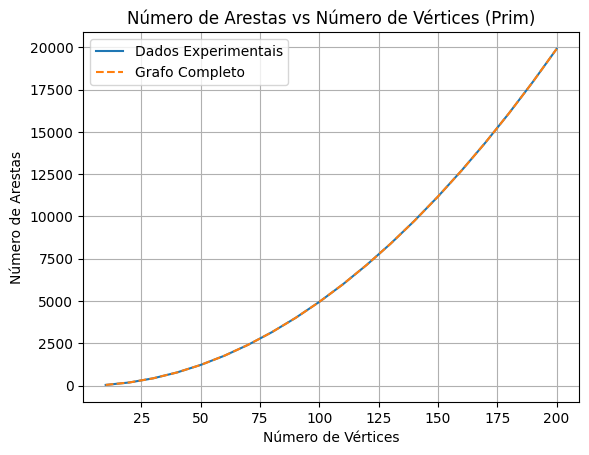

In [552]:
plotar(
    df_prim_vertice,
    linha=df_prim_vertice.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="num_arestas",
    titulo="Número de Arestas vs Número de Vértices (Prim)",
    xlabel="Número de Vértices",
    ylabel="Número de Arestas",
    funcao_comparacao=lambda x : (x * (x - 1)) / 2, # No pior caso, um grafo completo tem E = V(V-1)/2
    tlabel="Grafo Completo"
)

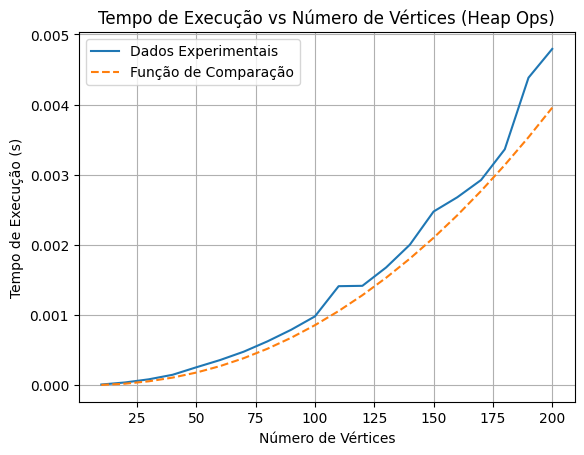

In [553]:
plotar(
    df_prim_vertice,
    linha=df_prim_vertice.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="tempo_execucao_heap_ops",
    titulo="Tempo de Execução vs Número de Vértices (Heap Ops)",
    xlabel="Número de Vértices",
    ylabel="Tempo de Execução (s)",
    funcao_comparacao=lambda x : 13e-9 * (x*(x-1)) * np.log2(x),
    tlabel="Função de Comparação"
)

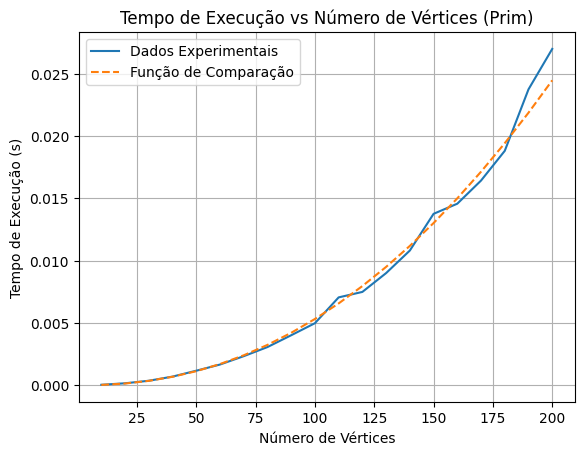

In [554]:
plotar(
    df_prim_vertice,
    linha=df_prim_vertice.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="tempo_execucao_total",
    titulo="Tempo de Execução vs Número de Vértices (Prim)",
    xlabel="Número de Vértices",
    ylabel="Tempo de Execução (s)",
    funcao_comparacao=lambda x : 8e-8 * (x**2) * np.log2(x),
    tlabel="Função de Comparação"
)

### Para o melhor caso, grafos espassos

In [555]:
df_prim_vertice2 = df_prim.sort_values(by="densidade", ascending=False)
df_prim_vertice2.drop_duplicates(subset="num_vertices", keep="last", inplace=True)
df_prim_vertice2.sort_values(by="num_vertices", inplace=True)
df_prim_vertice2.reset_index(drop=True, inplace=True)
df_prim_vertice2

,idx,num_vertices,num_arestas,densidade,arestas_analisadas,heap_push,heap_pop,tempo_execucao_heap_ops,num_arestas_mst,tempo_execucao_total
0,1,10,4,0.088889,4,8,8,2.807992e-06,4,0.000015
1,23,20,8,0.042105,1,2,2,5.600014e-07,1,0.000004
2,45,30,14,0.032184,2,4,4,7.320014e-07,2,0.000005
3,67,40,30,0.038462,19,46,46,4.946989e-06,19,0.000025
4,89,50,35,0.028571,17,36,36,4.220008e-06,17,0.000021
5,111,60,52,0.029379,43,96,96,1.081800e-05,43,0.000048
6,133,70,67,0.027743,47,116,116,1.199900e-05,47,0.000054
7,155,80,82,0.025949,66,164,164,1.883303e-05,66,0.000080
8,177,90,118,0.029463,81,234,234,2.469199e-05,81,0.000107
9,199,100,140,0.028283,95,280,280,2.963402e-05,95,0.000134


Para densidades baixas, $E ≈ V$

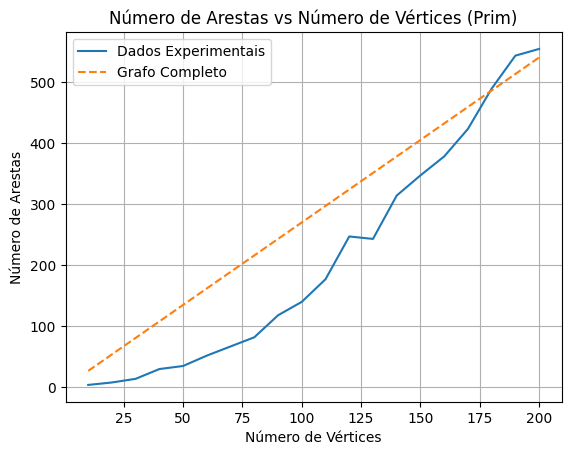

In [569]:
plotar(
    df_prim_vertice2,
    linha=df_prim_vertice2.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="num_arestas",
    titulo="Número de Arestas vs Número de Vértices (Prim)",
    xlabel="Número de Vértices",
    ylabel="Número de Arestas",
    funcao_comparacao=lambda x : 2.7*x, # No melhor caso, um grafo esparso tem E = V/2
    tlabel="Grafo Completo"
)

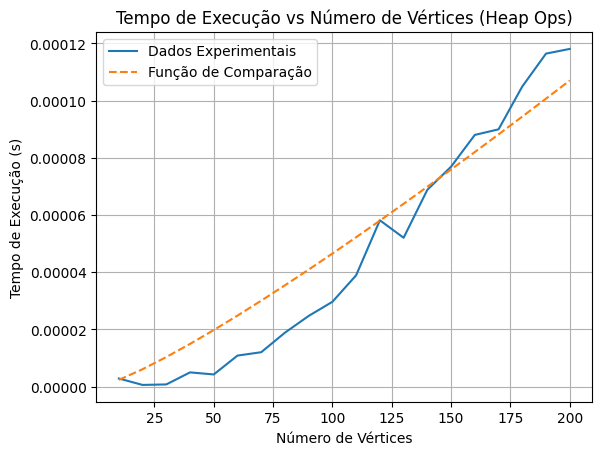

In [557]:
plotar(
    df_prim_vertice2,
    linha=df_prim_vertice2.shape[0] - 1,
    coluna1="num_vertices",
    coluna2="tempo_execucao_heap_ops",
    titulo="Tempo de Execução vs Número de Vértices (Heap Ops)",
    xlabel="Número de Vértices",
    ylabel="Tempo de Execução (s)",
    funcao_comparacao=lambda x : 7e-8 * x * np.log2(x),
    tlabel="Função de Comparação"
)

### Conclusão
Ao se fixar a densidado, as arestas aumentam em $O(V²)$, assim a complexidade do Prim, dado por $O(E \log{V})$, transforma-se em $O(V^2 \log{V})$. Isso é refletido no tempo de execução total e no tempo de execução das operações do Heap, no pior caso. Nos melhores casos, o algoritmo tende a ser $O(V \log{V})$

## Análise do algorimto Prim com o aumento da densidade do grafo

In [558]:
df_prim_densidade = df_prim.sort_values(by="densidade")
maior_num_vertice = df_prim_densidade["num_vertices"].max()
df_prim_densidade = df_prim_densidade[df_prim_densidade["num_vertices"] == maior_num_vertice]
df_prim_densidade.reset_index(drop=True, inplace=True)
df_prim_densidade

,idx,num_vertices,num_arestas,densidade,arestas_analisadas,heap_push,heap_pop,tempo_execucao_heap_ops,num_arestas_mst,tempo_execucao_total
0,419,200,554,0.027839,199,1108,1108,0.000118,199,0.000520
1,421,200,2586,0.129950,199,5172,5172,0.000674,199,0.002738
2,423,200,4553,0.228794,199,9106,9106,0.001101,199,0.004886
3,425,200,6684,0.335879,199,13368,13368,0.001516,199,0.007232
4,427,200,8663,0.435327,199,17326,17326,0.001827,199,0.009489
5,429,200,10494,0.527337,199,20988,20988,0.002182,199,0.011607
6,431,200,12459,0.626080,199,24918,24918,0.002642,199,0.014231
7,433,200,14433,0.725276,199,28866,28866,0.003209,199,0.017538
8,435,200,16523,0.830302,199,33046,33046,0.003661,199,0.019958
9,437,200,18490,0.929146,199,36980,36980,0.004021,199,0.023207


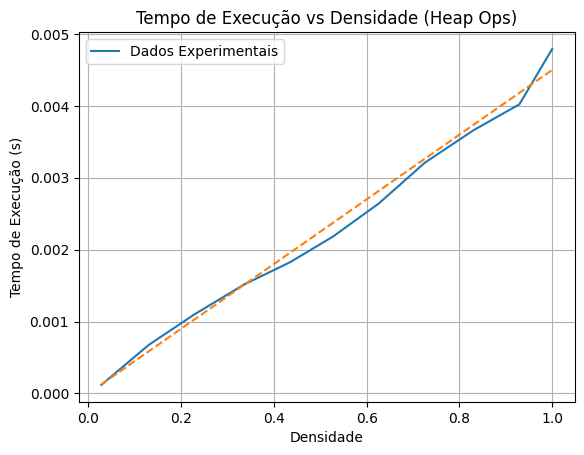

In [564]:
plotar(
    df_prim_densidade,
    linha=df_prim_densidade.shape[0] - 1,
    coluna1="densidade",
    coluna2="tempo_execucao_heap_ops",
    titulo="Tempo de Execução vs Densidade (Heap Ops)",
    xlabel="Densidade",
    ylabel="Tempo de Execução (s)",
    funcao_comparacao= lambda x : 0.0045 * x
)

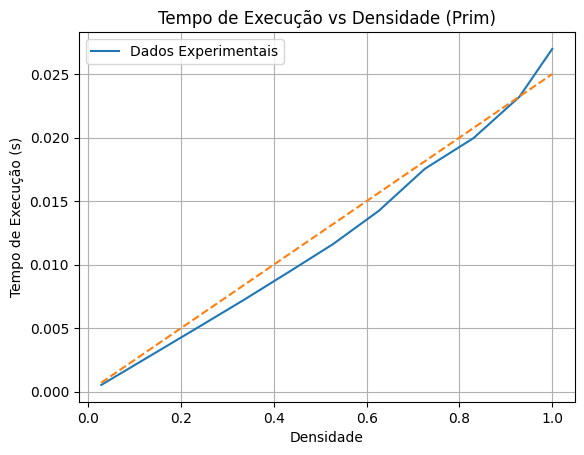

In [565]:
plotar(
    df_prim_densidade,
    linha=df_prim_densidade.shape[0] - 1,
    coluna1="densidade",
    coluna2="tempo_execucao_total",
    titulo="Tempo de Execução vs Densidade (Prim)",
    xlabel="Densidade",
    ylabel="Tempo de Execução (s)",
    funcao_comparacao= lambda x : 0.025 * x
)

### Conclusão
Ao fixar os vértices, a complexidade do Prim aumente pela função O(E), e visto que a densidade é proporcional ao número de arestas, pode-se dizer que o aumento da densidade resulta no aumento linear do tempo de execução

## Comparação do tempo gasto pelas operações do heap com o tempo gasto na totalidade

In [561]:
df_prim_copia = df_prim.copy()
df_prim_copia["porcentagem_heap_ops"] = (df_prim_copia["tempo_execucao_heap_ops"] / df_prim_copia["tempo_execucao_total"]) * 100
df_prim_copia

,idx,num_vertices,num_arestas,densidade,arestas_analisadas,heap_push,heap_pop,tempo_execucao_heap_ops,num_arestas_mst,tempo_execucao_total,porcentagem_heap_ops
0,1,10,4,0.088889,4,8,8,0.000003,4,0.000015,19.249963
1,3,10,7,0.155556,5,14,14,0.000002,5,0.000012,16.511540
2,5,10,12,0.266667,9,24,24,0.000005,9,0.000034,14.370629
3,7,10,13,0.288889,9,26,26,0.000003,9,0.000015,20.193376
4,9,10,16,0.355556,9,32,32,0.000003,9,0.000017,20.568519
...,...,...,...,...,...,...,...,...,...,...,...
215,431,200,12459,0.626080,199,24918,24918,0.002642,199,0.014231,18.564232
216,433,200,14433,0.725276,199,28866,28866,0.003209,199,0.017538,18.299027
217,435,200,16523,0.830302,199,33046,33046,0.003661,199,0.019958,18.344149
218,437,200,18490,0.929146,199,36980,36980,0.004021,199,0.023207,17.327741


Recuperando o maior valor

In [562]:
df_prim_copia["porcentagem_heap_ops"].max()

np.float64(27.678897209133062)

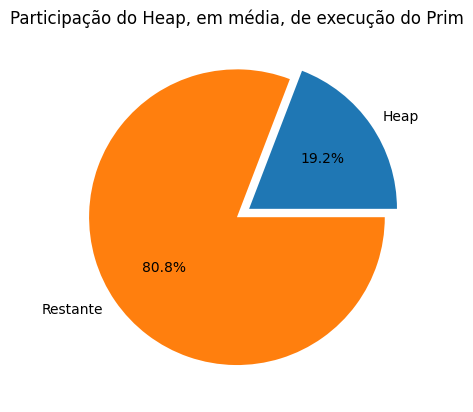

In [563]:
tempo_heap = df_prim["tempo_execucao_heap_ops"].mean()
tempo_total = df_prim["tempo_execucao_total"].mean()
tempo_resto = tempo_total - tempo_heap

plt.figure()
plt.pie(
    [tempo_heap, tempo_resto],
    labels=["Heap", "Restante"],
    autopct="%1.1f%%",
    explode=[0.1, 0]
)
plt.title("Participação do Heap, em média, de execução do Prim")
plt.show()

### Conclusão
O tempo gasto nas operações do heap equivale, em média, a 20% do total do tempo de execução, evidenciando que as outras operações consomem mais tempo que a estrutura de prioridade